In [1]:
from djchurchland.schema import Chipmunk

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from natsort import natsorted

new_rc_params = {"text.usetex": False, "svg.fonttype": "none"}
mpl.rcParams.update(new_rc_params)
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams["font.size"] = 12

%matplotlib widget
%load_ext autoreload
%autoreload 2

[2025-10-07 02:07:07,091][INFO]: Connecting gabriel@localhost:3306
[2025-10-07 02:07:07,098][INFO]: Connected gabriel@localhost:3306


In [2]:
good_trials = (
    Chipmunk.Trial()
    & "subject_name = 'GRB006'"
    & "session_datetime LIKE '2024-07-23%'"
    & "with_choice = 1"
).fetch("trial_number")
stim_rate = (
    Chipmunk.TrialParameters()
    & "subject_name = 'GRB006'"
    & "session_datetime LIKE '2024-07-23%'"
    & f"trial_number IN {tuple(good_trials)}"
).fetch("stim_rate")
rewarded = (
    Chipmunk.Trial()
    & "subject_name = 'GRB006'"
    & "session_datetime LIKE '2024-07-23%'"
    & f"trial_number IN {tuple(good_trials)}"
).fetch("rewarded")
data = pd.DataFrame({"stim_rate": stim_rate, "rewarded": rewarded})
data

,stim_rate,rewarded
0,18.0,1
1,14.0,1
2,6.0,1
3,20.0,1
4,5.0,1
...,...,...
392,16.0,0
393,20.0,1
394,16.0,1
395,10.0,1


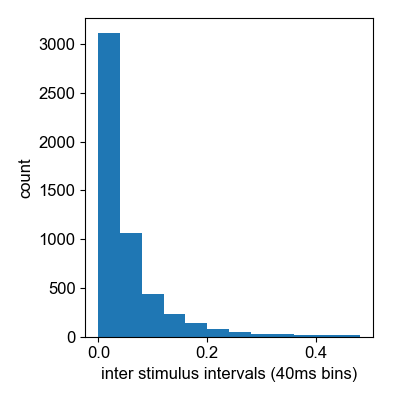

In [3]:
isi = np.hstack(
    (
        Chipmunk.TrialParameters()
        & "subject_name = 'GRB006'"
        & "session_datetime LIKE '2024-07-23%'"
        & f"trial_number IN {tuple(good_trials)}"
    ).fetch("inter_stim_intervals")
)
fig, ax = plt.subplots(1, figsize=(4, 4))
ax.hist(isi, bins=np.arange(0, 0.5, 0.04))
ax.set_xlabel("inter stimulus intervals (40ms bins)")
ax.set_ylabel("count")
fig.tight_layout()

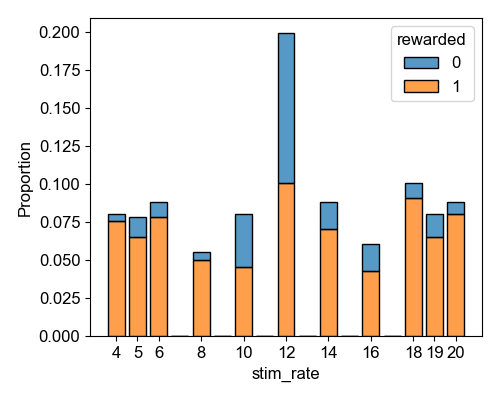

In [4]:
fig, ax = plt.subplots(1, figsize=(5, 4))
sns.histplot(
    data=data,
    x="stim_rate",
    hue="rewarded",
    multiple="stack",
    stat="proportion",
    discrete=True,
    shrink=0.8,
    ax=ax,
)
ax.set_xticks(natsorted(data.stim_rate.unique()))
fig.tight_layout()